--- Starting 5 Epsilon test of 10000 samples ---
Epsilon 0.001 done
Epsilon 0.0001 done
Epsilon 1e-05 done
Epsilon 1e-06 done
Epsilon 1e-07 done


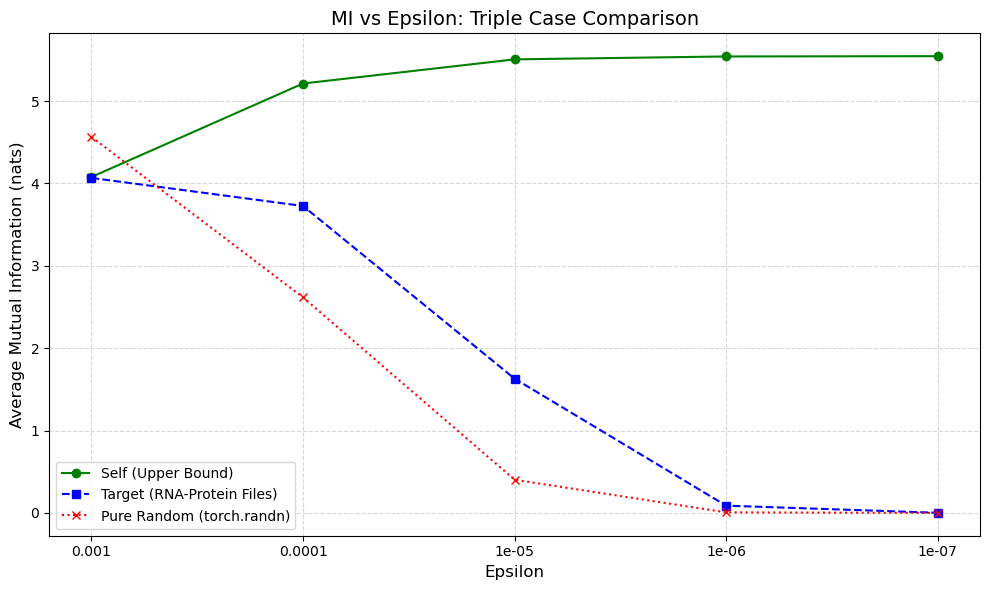

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc

def calculate_single_pair_mi(x_vec, y_vec, epsilon):
    diff = np.abs(x_vec[:, np.newaxis] - y_vec[np.newaxis, :])
    contingency_table = (diff < epsilon).astype(float)
    total_sum = np.sum(contingency_table)
    if total_sum == 0: return 0.0 
    
    p_xy = contingency_table / total_sum
    def get_entropy(p_dist):
        p = p_dist[p_dist > 0]
        return -np.sum(p * np.log(p))
    
    mi = get_entropy(np.sum(p_xy, axis=1)) + get_entropy(np.sum(p_xy, axis=0)) - get_entropy(p_xy)
    return max(0.0, mi)


def plot_mi_sweep_comparison(eps_list, num_samples=100):
    rna_data = np.load('nick_all_rna_embs.npy', mmap_mode='r')
    protein_data = np.load('nick_all_protein_embs.npy', mmap_mode='r')
    
    indices = np.random.choice(len(rna_data), num_samples, replace=False)
    
    target_results = []
    random_results = []
    self_results = []

    print(f"--- Starting {len(eps_list)} Epsilon test of {num_samples} samples ---")

    for eps in eps_list:
        t_mi, r_mi, s_mi = [], [], []
        for idx in indices:
            r_vec = rna_data[idx]
            p_vec = protein_data[idx]
            
            t_mi.append(calculate_single_pair_mi(r_vec, p_vec, eps))
            
            rnd_x = np.random.randn(512)
            rnd_y = np.random.randn(512)
            r_mi.append(calculate_single_pair_mi(rnd_x, rnd_y, eps))
            
            s_mi.append(calculate_single_pair_mi(r_vec, r_vec, eps))
            
        target_results.append(np.mean(t_mi))
        random_results.append(np.mean(r_mi))
        self_results.append(np.mean(s_mi))
        print(f"Epsilon {eps} done")

    plt.figure(figsize=(10, 6))
    eps_labels = [str(e) for e in eps_list]

    plt.plot(eps_labels, self_results, marker='o', linestyle='-', color='green', label='Self (Upper Bound)')
    plt.plot(eps_labels, target_results, marker='s', linestyle='--', color='blue', label='Target (RNA-Protein Files)')
    plt.plot(eps_labels, random_results, marker='x', linestyle=':', color='red', label='Pure Random (torch.randn)')

    plt.xlabel('Epsilon', fontsize=12)
    plt.ylabel('Average Mutual Information (nats)', fontsize=12)
    plt.title('MI vs Epsilon: Triple Case Comparison', fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

eps_to_test = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
plot_mi_sweep_comparison(eps_to_test, num_samples=10000)